목차 
- 주가 가져오기
- 주가 이동평균선
- 수익률과 위험
- 수익률 시각화
- 주식 베타
- 채권만기수익률
- 채권 듀레이션

## 1. 주가 가져오기

In [3]:
# Colab에서 최초 1회 설치
!pip -q install pykrx
# 라이브러리 불러오기
from pykrx import stock
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 조회 조건
start_date = "20230101"
end_date = "20251231"
ticker = "005930"   # 삼성전자

# 삼성전자 OHLCV 데이터 불러오기
df = stock.get_market_ohlcv_by_date(
    start_date,
    end_date,
    ticker
)

# 데이터 확인
print(df.head(10))
print(df.tail(10))
print("데이터 개수:", len(df))

# 데이터가 비어 있는지 확인
if df.empty:
    raise ValueError("주가 데이터가 없습니다. 조회 기간과 종목코드를 확인하세요.")

# 종가를 실수형으로 변환
price = df["종가"].astype(float)

               시가     고가     저가     종가       거래량       등락률
날짜                                                        
2023-01-02  55500  56100  55200  55500  10031448  0.361664
2023-01-03  55400  56000  54500  55400  13547030 -0.180180
2023-01-04  55700  58000  55600  57800  20188071  4.332130
2023-01-05  58200  58800  57600  58200  15682826  0.692042
2023-01-06  58300  59400  57900  59000  17334989  1.374570
2023-01-09  59700  60700  59600  60700  18640107  2.881356
2023-01-10  60200  61100  59900  60400  14859797 -0.494234
2023-01-11  61000  61200  60300  60500  12310751  0.165563
2023-01-12  61100  61200  59900  60500  16102561  0.000000
2023-01-13  60500  61200  60400  60800  12510328  0.495868
                시가      고가      저가      종가       거래량       등락률
날짜                                                            
2025-12-16  104900  105600  102700  102800  18852079 -1.908397
2025-12-17  103500  108100  103400  107900  22297611  4.961089
2025-12-18  106400  108200  105700  1076

## 2. 주가이동평균선

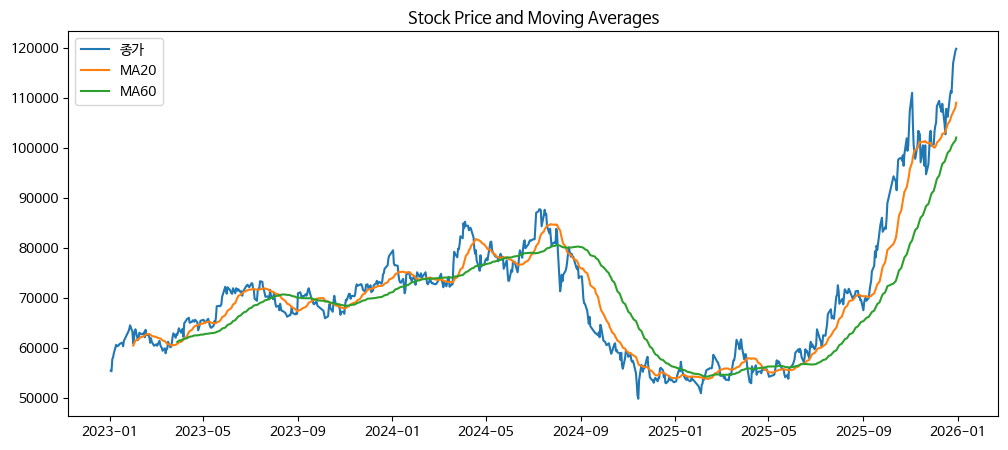

In [8]:
df["MA20"] = df["종가"].rolling(window=20).mean()
df["MA60"] = df["종가"].rolling(window=60).mean()

plt.figure(figsize=(12, 5))
plt.plot(df["종가"], label="종가")
plt.plot(df["MA20"], label="MA20")
plt.plot(df["MA60"], label="MA60")
plt.legend()
plt.title("Stock Price and Moving Averages")
plt.show()

## 3. 일별수익률과 위험 (표준편차)

In [6]:
# 일별 수익률 계산
daily_return = price.pct_change().dropna()

# 일평균 수익률
mean_daily_return = daily_return.mean()

# 일별 위험: 수익률 표준편차
daily_risk = daily_return.std()

# 연환산 수익률: 산술평균 방식
annual_return = mean_daily_return * 252

# 연환산 위험
annual_risk = daily_risk * np.sqrt(252)

# 결과 출력
print(f"평균 일별수익률: {mean_daily_return * 100:.4f}%")
print(f"일별 위험(표준편차): {daily_risk * 100:.4f}%")
print(f"연환산 수익률: {annual_return * 100:.2f}%")
print(f"연환산 위험(변동성): {annual_risk * 100:.2f}%")

평균 일별수익률: 0.1232%
일별 위험(표준편차): 1.8791%
연환산 수익률: 31.04%
연환산 위험(변동성): 29.83%


In [ ]:
# 정규분포를 가정하면, 수익률은 평균을 중심으로 약 95%가 평균 ± 1.96×표준편차 범위에 존재한다고 해석할 수 있습니다.
# 다만 이것은 엄밀히 말해 평균수익률의 95% 신뢰구간이 아니라, 개별 기간 수익률이 나타날 것으로 예상되는 약 95% 확률구간입니다.
# 1. 일별수익률의 95% 범위
# 평균 일별수익률: 0.1232%
# 일별 표준편차: 1.8791%
# 계산식:
# 일별수익률의 95% 범위
# = 평균 일별수익률 ± 1.96 × 일별 표준편차

# 하한:
# = 0.1232% - 1.96 × 1.8791%
# = -3.5598%
# 상한:
# = 0.1232% + 1.96 × 1.8791%
# = 3.8062%

# 따라서:
# 약 -3.56% ~ +3.81%
# 해석
# 정규분포 가정이 적절하고 과거와 같은 수익률 구조가 유지된다면, 삼성전자의 하루 수익률은 약 95%의 확률로 -3.56%에서 +3.81% 사이에 나타날 것으로 해석할 수 있습니다.
# 반대로 이 범위를 벗어날 확률은 약 5%입니다.
# -3.56%보다 낮을 확률: 약 2.5%
# +3.81%보다 높을 확률: 약 2.5%

In [ ]:
# 연환산 수익률과 위험의 해석
# 연환산 수익률: 31.04%
# 연환산 위험: 29.83%

# 같은 방식으로 단순 계산하면:
# 연간 수익률의 95% 범위
# = 31.04% ± 1.96 × 29.83%
# 하한:
# = 31.04% - 58.47%
# = -27.43%
# 상한:
# = 31.04% + 58.47%
# = 89.51%
# 따라서 단순 정규분포 가정에 따른 연간 수익률 범위는:
# 약 -27.43% ~ +89.51%
# 해석
# 과거의 평균과 변동성이 앞으로도 유지되고 연간수익률이 정규분포를 따른다고 단순 가정하면, 
#     삼성전자의 1년 수익률은 약 95% 확률로 -27.43%에서 +89.51% 사이에 있을 수 있다는 의미입니다.

## 4. 주가와 일별 수익률 시각화

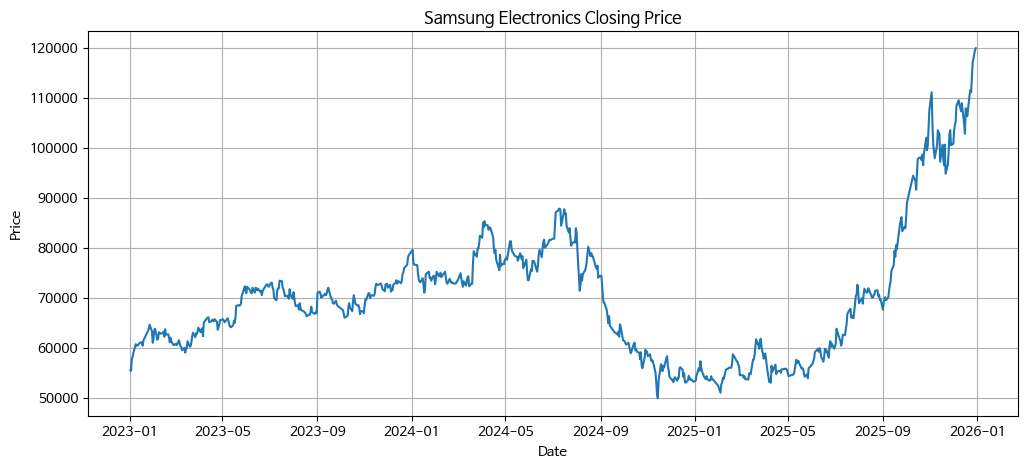

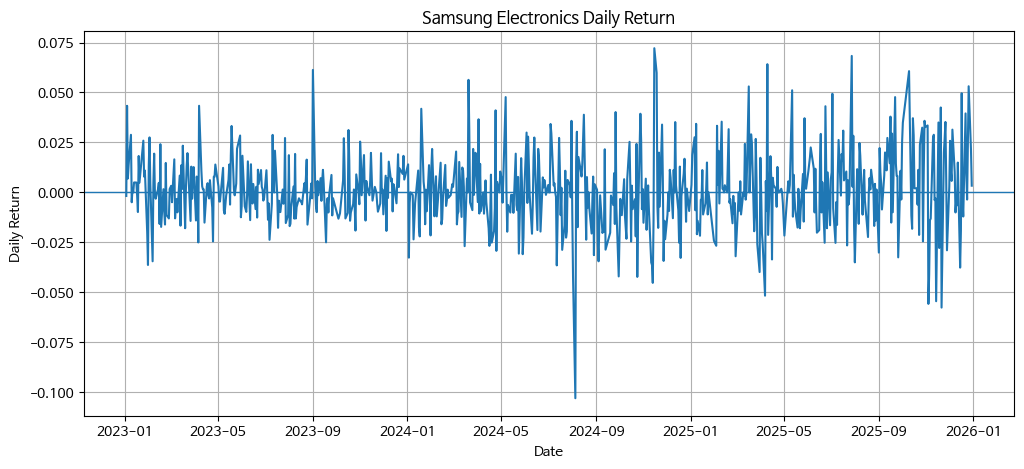

In [4]:
# 삼성전자 종가
plt.figure(figsize=(12, 5))
plt.plot(price)
plt.title("Samsung Electronics Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# 삼성전자 일별 수익률
plt.figure(figsize=(12, 5))
plt.plot(daily_return)
plt.title("Samsung Electronics Daily Return")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.axhline(0, linewidth=1)
plt.grid(True)
plt.show()

## 5. 주식 베타 (삼성전자)

In [ ]:
# 베타
# = 삼성전자 수익률과 KOSPI 수익률의 공분산
#   ÷ KOSPI 수익률의 분산

# 수학적으로는:

# β = Cov(R삼성전자, RKOSPI) / Var(RKOSPI)
# kospi 대용치 --> KODEX 200 ETF

In [6]:
from pykrx import stock
import pandas as pd
import numpy as np

# 조회 기간
start_date = "20260101"
end_date = "20260731"

# 종목 코드
samsung_ticker = "005930"   # 삼성전자
market_ticker = "069500"    # KODEX 200 ETF

# 삼성전자 데이터
samsung_df = stock.get_market_ohlcv_by_date(
    start_date,
    end_date,
    samsung_ticker
)

# KODEX 200 데이터
market_df = stock.get_market_ohlcv_by_date(
    start_date,
    end_date,
    market_ticker
)

# 데이터 확인
print("삼성전자 데이터 수:", len(samsung_df))
print("KODEX 200 데이터 수:", len(market_df))

if samsung_df.empty:
    raise ValueError("삼성전자 데이터를 불러오지 못했습니다.")

if market_df.empty:
    raise ValueError("KODEX 200 데이터를 불러오지 못했습니다.")

# 종가 추출
samsung_price = samsung_df["종가"].astype(float)
market_price = market_df["종가"].astype(float)

# 일별수익률
samsung_return = samsung_price.pct_change()
market_return = market_price.pct_change()

# 날짜 기준 결합
returns = pd.concat(
    [samsung_return, market_return],
    axis=1
)

returns.columns = [
    "Samsung_Return",
    "Market_Return"
]

returns = returns.dropna()

# 베타 계산
covariance = returns["Samsung_Return"].cov(
    returns["Market_Return"]
)

market_variance = returns["Market_Return"].var()

beta = covariance / market_variance

print("관측치 수:", len(returns))
print(f"공분산: {covariance:.8f}")
print(f"시장수익률 분산: {market_variance:.8f}")
print(f"삼성전자 베타: {beta:.4f}")

삼성전자 데이터 수: 142
KODEX 200 데이터 수: 142
관측치 수: 141
공분산: 0.00248299
시장수익률 분산: 0.00210992
삼성전자 베타: 1.1768


### 회귀분석으로 베타 계산하기

In [ ]:
# 베타는 시장수익률을 독립변수로 하고 삼성전자 수익률을 종속변수로 한 회귀분석의 기울기와 같습니다.

In [4]:
import statsmodels.api as sm

# 독립변수: 시장수익률
X = returns["Market_Return"]
X = sm.add_constant(X)

# 종속변수: 삼성전자 수익률
y = returns["Samsung_Return"]

# 회귀분석
model = sm.OLS(y, X).fit()

alpha = model.params["const"]
beta_regression = model.params["Market_Return"]

print(f"알파: {alpha:.6f}")
print(f"회귀분석 베타: {beta_regression:.4f}")

print(model.summary())

알파: -0.000149
회귀분석 베타: 1.1838
                            OLS Regression Results                            
Dep. Variable:         Samsung_Return   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     1203.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):          2.44e-156
Time:                        03:47:42   Log-Likelihood:                 2222.0
No. Observations:                 730   AIC:                            -4440.
Df Residuals:                     728   BIC:                            -4431.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           

### 산점도와 회귀선

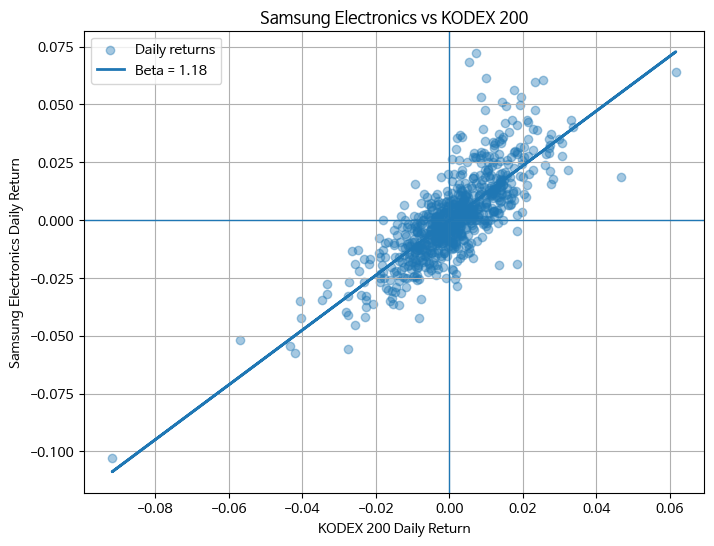

In [5]:
import matplotlib.pyplot as plt
import numpy as np

x = returns["Market_Return"]
y = returns["Samsung_Return"]

slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.4,
    label="Daily returns"
)

plt.plot(
    x,
    intercept + slope * x,
    linewidth=2,
    label=f"Beta = {slope:.2f}"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("Samsung Electronics vs KODEX 200")
plt.xlabel("KODEX 200 Daily Return")
plt.ylabel("Samsung Electronics Daily Return")
plt.legend()
plt.grid(True)
plt.show()

## 6. 채권 만기수익률 계산

In [12]:
!pip install numpy-financial

In [7]:
# 액면가 10000 시장가격 9500 표면이율 5% 연이자지급 이표채 만기 3년

import numpy_financial as npf

cash_flows = [-9500, 500, 500, 10500]

ytm = npf.irr(cash_flows)

print("만기수익률:", ytm)

만기수익률: 0.06901842451827966


## 7. 채권 듀레이션 계산

In [8]:
price = 9500
ytm = ytm

cash_flows = [500, 500, 10500]
periods = [1, 2, 3]

pv_cash_flows = [
    cf / (1 + ytm) ** t
    for cf, t in zip(cash_flows, periods)
]

duration = sum(
    t * pv
    for t, pv in zip(periods, pv_cash_flows)
) / price

print("듀레이션:", duration)

듀레이션: 2.855477968574527
